# Analyze Singular Value Spectrum

In [3]:
import sys
import os

from pathlib import Path
from itertools import islice
sys.path.append(os.path.abspath('..'))

In [4]:
import matplotlib.pyplot as plt
import numpy as np
#Load fine tuned gpt2 model
import torch

from src.svd_compression import compute_svd

In [5]:
# For NumPy
np.random.seed(42)


In [11]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load the checkpoint dictionary
state_dict = torch.load("./../checkpoints/gpt2/full_finetune_best_model.pt",map_location=device)

# 2. Extract one layer's weights (e.g., the first MLP layer) and convert to NumPy
weight_matrix = state_dict['transformer.h.0.mlp.c_fc.weight'].numpy()

# 3. Compute the SVD on the learned weights
U, S, Vt = compute_svd(weight_matrix)

In [ ]:

print(S)

[45.07198539 44.36577252 44.06594906 43.98775233 43.53561745 43.15998225
 42.99391018 42.89621058 42.5260807  42.39776598 41.99599189 41.93635632
 41.92086577 41.70622791 41.5719968  41.5125866  41.2628399  40.95621824
 40.89509966 40.82127948 40.72203501 40.55912962 40.45346667 40.26500033
 40.04622656 39.98230663 39.83737784 39.64913542 39.57497184 39.34967584
 39.25705035 39.12556427 38.94423235 38.85396669 38.62820164 38.49781614
 38.45851854 38.07018385 38.02098305 37.96113169 37.79559701 37.68822796
 37.62070174 37.46921822 37.37180274 37.30782936 37.1780871  37.02852934
 36.77543789 36.6403689  36.48287315 36.41830492 36.28750622 36.20317329
 36.06246075 35.97035509 35.88635049 35.74907743 35.72218199 35.59265984
 35.36416704 35.27653746 35.19016139 35.12372238 34.95525544 34.90833282
 34.80417319 34.72444485 34.59673359 34.50268196 34.33630876 34.23963167
 34.09896854 34.03528242 33.86867518 33.84446683 33.74331178 33.58757372
 33.50266596 33.33626357 33.1658686  33.13713264 33

/tmp/ipykernel_1497847/3469593247.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


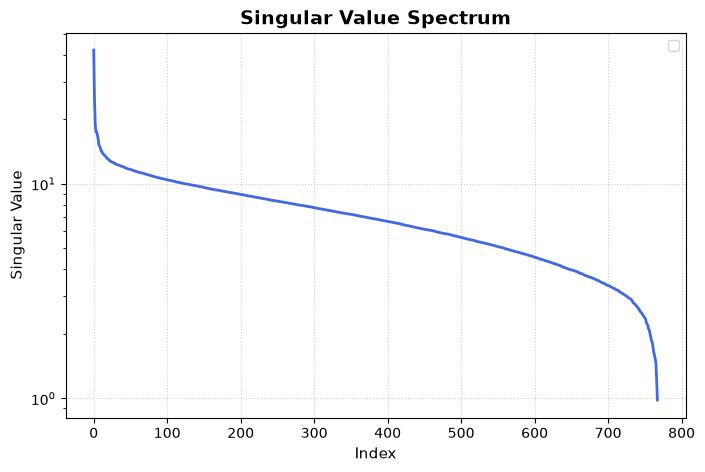

In [14]:


# Datasets
x_indices = range(len(S))
# Adjust layout window size
plt.figure(figsize=(8, 5))


#plt.plot(x, y)
# Plot lines with custom colors, symbols (markers), and styles
plt.plot( x_indices,S, color='royalblue', linewidth=2)

# Meta properties 
plt.title('Singular Value Spectrum', fontsize=14, fontweight='bold')
plt.xlabel('Index', fontsize=11)
plt.ylabel('Singular Value', fontsize=11)

# Formatting elements
plt.grid(True, linestyle=':', alpha=0.6) # Add soft gridlines
plt.legend()  
# Show color tags block


plt.yscale('log')

# Save the final figure
filepath = Path('./../experiments/singular_values.png')
plt.savefig(filepath)

# Render output
plt.show()
